In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

np.random.seed(0)   # reproducible runs

##Perceptron code for Logistic Regression


In [2]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, random_state=41
                          , n_classes=2, n_clusters_per_class=1,hypercube=False, class_sep=20)

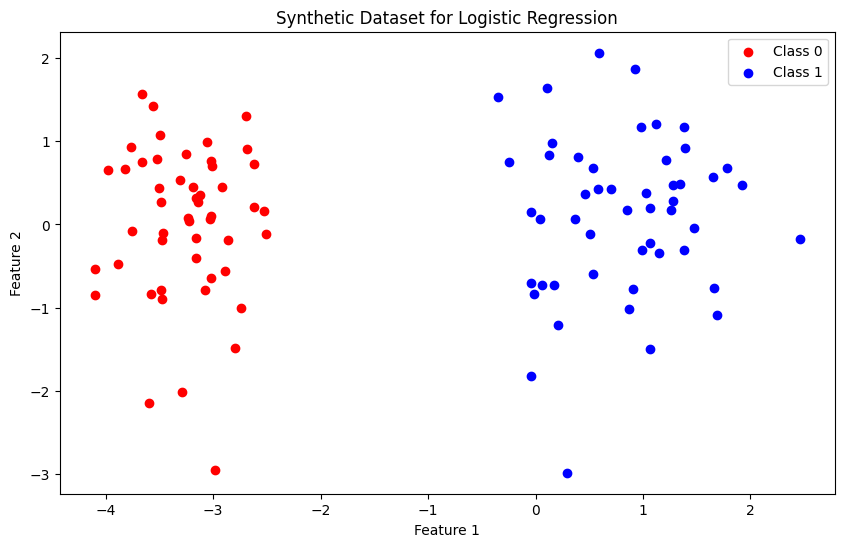

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', label='Class 0')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='Class 1')
plt.title('Synthetic Dataset for Logistic Regression')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()


In [4]:
X,y

(array([[ 0.51123145, -0.11697552],
        [ 0.06316371, -0.73115232],
        [-0.0425064 , -0.7081059 ],
        [-3.2891569 , -2.01199214],
        [ 0.1111445 ,  1.63493163],
        [-2.53070306,  0.15599044],
        [-3.49036198,  1.07782053],
        [ 0.3976447 ,  0.80626713],
        [-0.24666899,  0.74859527],
        [-3.65803446,  0.75152794],
        [-3.47658131, -0.90114581],
        [-3.47815037, -0.1815243 ],
        [ 0.29004249, -2.98092432],
        [ 1.11761831,  1.20500136],
        [-3.52530398,  0.78302407],
        [ 0.69929128,  0.42968688],
        [ 0.17089733, -0.73229726],
        [-3.57785124, -0.83930476],
        [ 0.12965489,  0.83727062],
        [-3.46888717, -0.10255323],
        [-3.97487212,  0.65867001],
        [-3.76348686,  0.92649819],
        [-3.01519735,  0.10216193],
        [ 1.92241659,  0.46886454],
        [-2.91479578,  0.45432938],
        [ 0.9259563 ,  1.8613386 ],
        [-3.4859014 , -0.79255991],
        [-2.73978345, -1.000

In [5]:
def step(x):
    return 1 if x >= 0 else 0

In [6]:
def perceptron(X,y):
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.ones(X.shape[1])  # Initialize weights
    lr = 0.1  # Learning rate

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))
        weights += lr * (y[j] - y_hat)*X[j]

    return weights[0], weights[1:]



In [7]:
intercept, coefficients = perceptron(X,y)

In [8]:
X

array([[ 0.51123145, -0.11697552],
       [ 0.06316371, -0.73115232],
       [-0.0425064 , -0.7081059 ],
       [-3.2891569 , -2.01199214],
       [ 0.1111445 ,  1.63493163],
       [-2.53070306,  0.15599044],
       [-3.49036198,  1.07782053],
       [ 0.3976447 ,  0.80626713],
       [-0.24666899,  0.74859527],
       [-3.65803446,  0.75152794],
       [-3.47658131, -0.90114581],
       [-3.47815037, -0.1815243 ],
       [ 0.29004249, -2.98092432],
       [ 1.11761831,  1.20500136],
       [-3.52530398,  0.78302407],
       [ 0.69929128,  0.42968688],
       [ 0.17089733, -0.73229726],
       [-3.57785124, -0.83930476],
       [ 0.12965489,  0.83727062],
       [-3.46888717, -0.10255323],
       [-3.97487212,  0.65867001],
       [-3.76348686,  0.92649819],
       [-3.01519735,  0.10216193],
       [ 1.92241659,  0.46886454],
       [-2.91479578,  0.45432938],
       [ 0.9259563 ,  1.8613386 ],
       [-3.4859014 , -0.79255991],
       [-2.73978345, -1.0004391 ],
       [-4.09896768,

In [9]:
print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 1.2000000000000002
Coefficients: [1.0580085  0.40381514]


In [10]:
# get m and b
m = -coefficients[0]/coefficients[1]
b = -intercept/coefficients[1]

In [11]:
print(m,b)

-2.6200317952788446 -2.9716568071029252


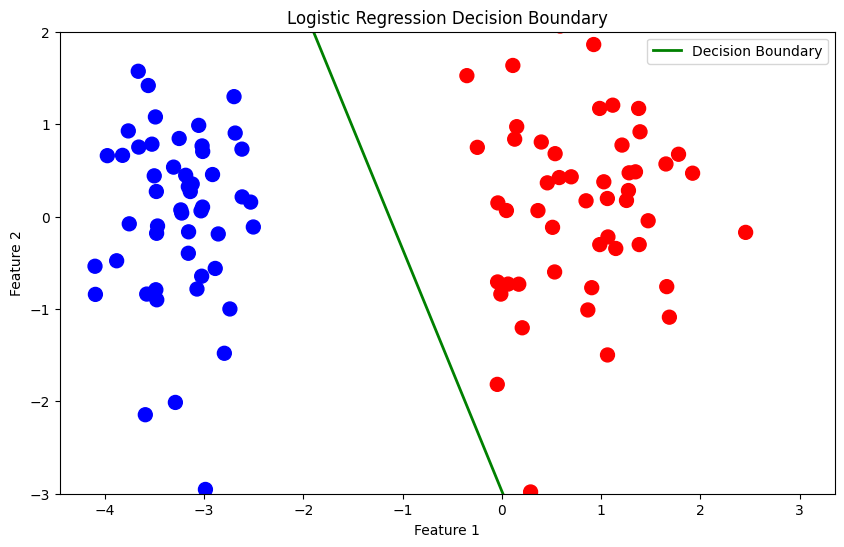

In [12]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

plt.figure(figsize=(10,6))

plt.plot(x_input, y_input, color='green', label='Decision Boundary', linewidth=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)
plt.title('Logistic Regression Decision Boundary')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

## Using Sigmoid function for Logistic Regression
just changing the step function to sigmoid function

In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # Clip z to avoid overflow
    return 1 / (1 + np.exp(-z))

In [14]:
def perceptron_sigmoid(X,y):
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.ones(X.shape[1])  # Initialize weights
    lr = 0.1  # Learning rate

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j], weights))
        weights += lr * (y[j] - y_hat)*X[j]

    return y_hat, weights[0], weights[1:]

In [15]:
y_hat, intercept_sigmoid, coefficients_sigmoid = perceptron_sigmoid(X,y)
print("Intercept (Sigmoid):", intercept_sigmoid)
print("Coefficients (Sigmoid):", coefficients_sigmoid)
print("Predicted probabilities (Sigmoid):", y_hat)

Intercept (Sigmoid): 2.8994486311543435
Coefficients (Sigmoid): [2.8473855  0.15450609]
Predicted probabilities (Sigmoid): 0.9994680919903756


In [16]:
# get m and b for sigmoid
m_sigmoid = -coefficients_sigmoid[0]/coefficients_sigmoid[1]
b_sigmoid = -intercept_sigmoid/coefficients_sigmoid[1]
print(m_sigmoid,b_sigmoid)


-18.428953006385772 -18.765917926954636


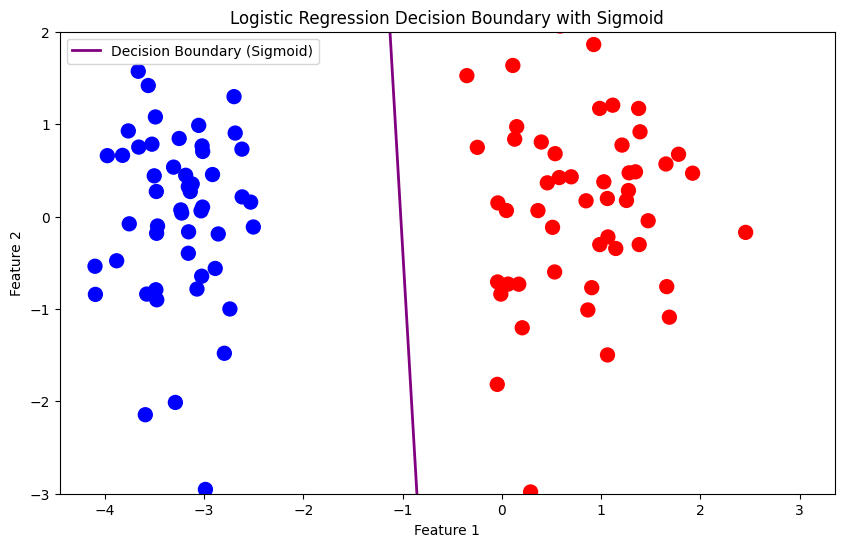

In [17]:
x_input_sigmoid = np.linspace(-3, 3, 100)
y_input_sigmoid = m_sigmoid*x_input_sigmoid + b_sigmoid

plt.figure(figsize=(10,6))
plt.plot(x_input_sigmoid, y_input_sigmoid, color='purple', label='Decision Boundary (Sigmoid)', linewidth=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)
plt.title('Logistic Regression Decision Boundary with Sigmoid')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

 this is not the best line so lets write the BCE loss , gradient descent later

In [18]:
def bce_loss(y_true, p):
    # clip p to [1e-12, 1-1e-12] to avoid log(0)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    loss = -np.mean(y_true*np.log(p)+ (1-y_true)*np.log(1-p))   
    return loss

In [19]:
# now that was on one value (on the last random sample), we need to calculate the BCE loss for all samples in the dataset. Let's modify the `bce_loss` function to compute the loss for all samples.
Xb = np.insert(X, 0, 1, axis=1)  # Add bias term to the dataset
w = np.concatenate(([intercept_sigmoid], coefficients_sigmoid))  # Combine intercept and coefficients into a single weight vector
p = sigmoid(np.dot(Xb, w))  # Compute predicted probabilities for all samples
print(bce_loss(y, p))  # Compute BCE loss for all samples



0.010951980854211648


In [20]:
Xb.shape[0]

100

## GD
Since GD uses the derivative of the loss, we write the update rule for the weights (bias included as w0).

Gradient of the BCE loss w.r.t. the weights (m = number of rows):

    dL/dw = (1/m) * X^T (p - y)        <- "prediction minus truth", averaged

so the update rule is:

    w = w - lr * (1/m) * X^T (p - y)

(equivalently  w = w + lr * (1/m) * X^T (y - p), which is what the code below computes).

In [21]:
def gd(X,y, learning_rate=0.5, epochs=5000):
    Xb = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.ones(Xb.shape[1])  # Initialize weights

    for epoch in range(epochs):
        p = sigmoid(np.dot(Xb, weights))  # Compute predicted probabilities
        gradient = -(1/Xb.shape[0]) * np.dot(Xb.T, (y - p))  # Compute gradient
        weights -= learning_rate * gradient  # Update weights

    return weights[0], weights[1:]  # Return intercept and coefficients

In [22]:
intercept_gd, coefficients_gd = gd(X,y)
print("Intercept (GD):", intercept_gd)
print("Coefficients (GD):", coefficients_gd)



Intercept (GD): 5.83338864905325
Coefficients (GD): [4.83926872 0.21182255]


In [23]:
m_gd = -coefficients_gd[0]/coefficients_gd[1]
b_gd = -intercept_gd/coefficients_gd[1]


In [24]:
x_input_gd = np.linspace(-3, 3, 100)
y_input_gd = m_gd*x_input_gd + b_gd


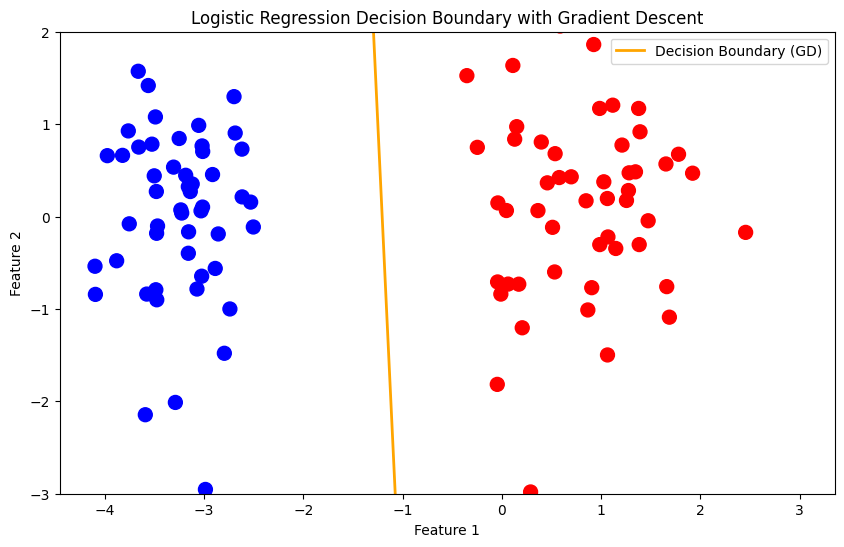

In [25]:
plt.figure(figsize=(10,6))
plt.plot(x_input_gd, y_input_gd, color='orange', label='Decision Boundary (GD)', linewidth=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)
plt.title('Logistic Regression Decision Boundary with Gradient Descent')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.legend()

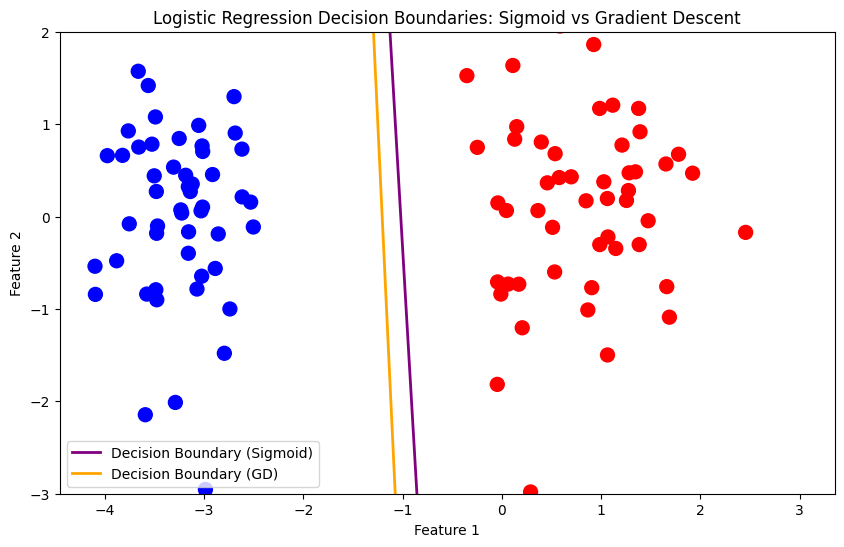

In [26]:
# now both sigmoid graph and gd graph in one graph
plt.figure(figsize=(10,6))
plt.plot(x_input_sigmoid, y_input_sigmoid, color='purple', label='Decision Boundary (Sigmoid)', linewidth=2)
plt.plot(x_input_gd, y_input_gd, color='orange', label='Decision Boundary (GD)', linewidth=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)
plt.title('Logistic Regression Decision Boundaries: Sigmoid vs Gradient Descent')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

## Gradient check
Before trusting `gd`, verify the analytic gradient `X^T (p - y) / m` against a finite-difference estimate
`(L(w + eps) - L(w - eps)) / (2 eps)` for each weight. If the formula is right, every difference is ~1e-8 or smaller.

In [27]:
def loss_at(w, Xb, y):
    return bce_loss(y, sigmoid(Xb @ w))

def analytic_grad(w, Xb, y):
    return Xb.T @ (sigmoid(Xb @ w) - y) / Xb.shape[0]

def numeric_grad(w, Xb, y, eps=1e-5):
    g = np.zeros_like(w)
    for j in range(w.size):
        e = np.zeros_like(w); e[j] = eps
        g[j] = (loss_at(w + e, Xb, y) - loss_at(w - e, Xb, y)) / (2 * eps)
    return g

Xb = np.insert(X, 0, 1, axis=1)
w0 = np.ones(Xb.shape[1])
a, n = analytic_grad(w0, Xb, y), numeric_grad(w0, Xb, y)
print("analytic:", a)
print("numeric :", n)
print("max |diff|:", np.max(np.abs(a - n)), "-> PASS" if np.max(np.abs(a - n)) < 1e-6 else "-> FAIL")

analytic: [-0.02532343 -0.23936018  0.09070199]
numeric : [-0.02532343 -0.23936018  0.09070199]
max |diff|: 2.0678569967458316e-11 -> PASS


## Loss history
Same `gd`, but record the loss every epoch so we can *see* convergence.

loss at epoch 0    : 0.18584952213353914
loss at last epoch : 0.0006328240501055581
weights            : [5.83338865 4.83926872 0.21182255]


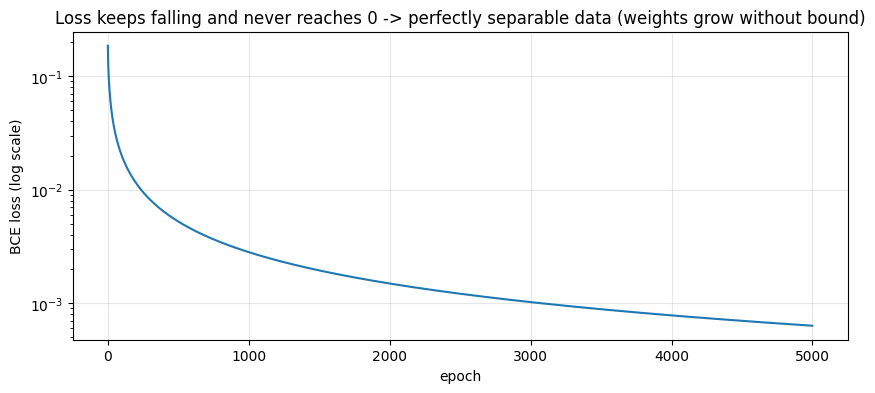

In [28]:
def gd_with_history(X, y, learning_rate=0.5, epochs=5000):
    Xb = np.insert(X, 0, 1, axis=1)
    w = np.ones(Xb.shape[1])
    history = np.empty(epochs)
    for epoch in range(epochs):
        p = sigmoid(Xb @ w)
        history[epoch] = bce_loss(y, p)
        w -= learning_rate * (Xb.T @ (p - y) / Xb.shape[0])
    return w, history

w_gd, history = gd_with_history(X, y)
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('BCE loss (log scale)')
plt.title('Loss keeps falling and never reaches 0 -> perfectly separable data (weights grow without bound)')
plt.grid(alpha=.3)
print("loss at epoch 0    :", history[0])
print("loss at last epoch :", history[-1])
print("weights            :", w_gd)

## Compare with sklearn
`class_sep=20` makes this dataset perfectly separable, so the unregularised optimum does not exist (weights grow forever).
sklearn's default `C=1.0` (L2) pins the weights down. Compare on **overlapping** data instead, where a finite optimum exists and both should agree.

In [29]:
from sklearn.linear_model import LogisticRegression

X2, y2 = make_classification(n_samples=500, n_features=3, n_informative=3, n_redundant=0,
                             random_state=7, class_sep=0.8)
w_ours, _ = gd_with_history(X2, y2, learning_rate=0.5, epochs=20000)
sk = LogisticRegression(C=np.inf, max_iter=10000).fit(X2, y2)   # C=inf -> no regularisation

print("ours    :", w_ours)
print("sklearn :", np.r_[sk.intercept_, sk.coef_.ravel()])
print("max |diff|:", np.max(np.abs(w_ours - np.r_[sk.intercept_, sk.coef_.ravel()])))

ours    : [ 0.29228661  1.46703639  0.7476263  -0.02126057]
sklearn : [ 0.29229132  1.46721456  0.74786008 -0.02112321]
max |diff|: 0.00023377492115916887


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
